In [1]:
import numpy as np
import matplotlib.pyplot as plt


x = 2 * np.random.rand(100 , 1)
y = 4 + 3 * x +np .random.randn(100 , 1)



In [2]:
print(x.shape)

(100, 1)


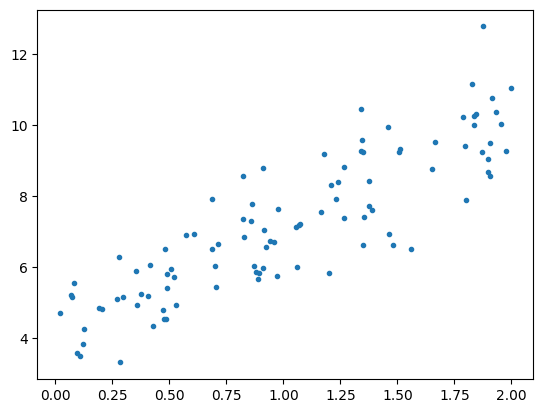

In [3]:
plt.plot( x  , y , ".")
plt.show()

In [4]:
x_b = np.c_[np.ones((100 , 1)) , x] # add x0 = 1 to each instance
theta = np.linalg.inv(x_b.T.dot(x_b)).dot(x_b.T.dot(y)) #Normal equation = (X^t * x)^-1 *X^T *y
                                                        #Gives the best value of thetha that minimizes the cost function
theta

array([[4.15633284],
       [3.00511528]])

In [5]:
x_new = np.array([[0] , [2]])
print(x_new.shape)
x_new_predict = np.c_[np.ones((2 , 1)) , x_new] #[np.ones((dimensions)) , same dimension ko object]
print(theta.shape)
y_predict = x_new_predict.dot(theta)
y_predict


(2, 1)
(2, 1)


array([[ 4.15633284],
       [10.16656341]])

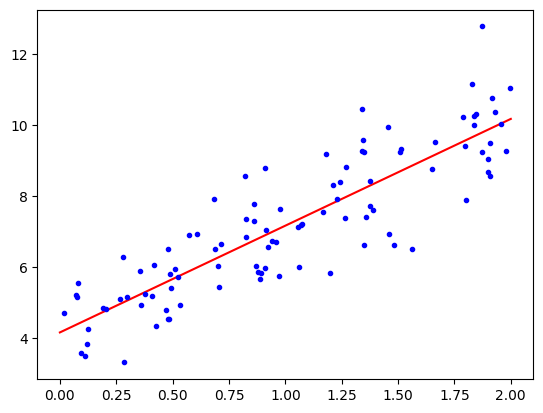

In [6]:
plt.plot(x_new , y_predict , "r-")
plt.plot(x , y, "b.")
plt.show()

In [7]:
#In terms of sklearn

from sklearn.linear_model import LinearRegression

linear = LinearRegression()
linear.fit(x , y)


LinearRegression()

In [8]:
print(linear.intercept_) #Bias thetha 
print(linear.coef_) # Feature weight

[4.15633284]
[[3.00511528]]


In [9]:
#Gradient descent implementation

eta = 0.1 #The learning rate
n_iterations = 1000
m = 100

theta = np.random.rand(2,1) #Since two values for the theta thetha0 and theta1


for iteration in range(n_iterations):
    gradient = (2/m) * x_b.T.dot(x_b.dot(theta) - y) #Uses whole training set in each iteration
    theta = theta - eta * gradient

theta


array([[4.15633284],
       [3.00511528]])

In [10]:
#Stiochastic Gradient descent implementation
n_epochs = 50
t0 , t1 = 5 ,50

theta_1 = np.random.rand(2 ,1)


def learning_rate(t):
    return t0 / (t + t1) #Take Large steps at first as t1>>t and as iteration increases then t>>t1 and small steps


for epochs in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        x_i = x_b[random_index : random_index + 1]
        y_i = y[random_index : random_index + 1]
        gradient = (2) * x_i.T.dot(x_i.dot(theta_1) - y_i) #This is the normal equation here
        eta = learning_rate(epochs * m + i)
        theta_1 = theta_1 - eta * gradient


In [11]:
theta_1

array([[4.1724621 ],
       [3.03634894]])

In [12]:
from sklearn.linear_model import SGDRegressor

regressor = SGDRegressor(n_iter_no_change = 50 , eta0=0.1 , penalty = None)
regressor.fit(x , y)



c:\Users\TRITON\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SGDRegressor(eta0=0.1, n_iter_no_change=50, penalty=None)

In [13]:
theta_0 = regressor.intercept_
theta = regressor.coef_


In [119]:
#Polynomial Regression
m = 100
x_pol = 6 * np.random.rand(m,1) - 3
y_pol = 0.5*  x_pol**2  + x_pol + 2 + np.random.rand(m , 1)

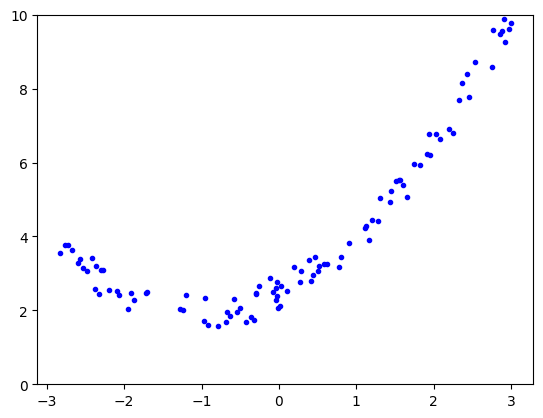

In [120]:
plt.plot(x_pol , y_pol , "b.")
plt.ylim(0 , 10)
plt.show()

In [121]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree= 2 , include_bias=False)
x_poly = poly_features.fit_transform(x_pol)

In [122]:
print(x_pol[0])
print(x_poly[0])

[1.91999789]
[1.91999789 3.68639189]


In [123]:
linear_reg = LinearRegression()
linear_reg.fit(x_poly , y_pol)


LinearRegression()

In [124]:
x_test = np.linspace(-3 , 3 , 200).reshape(-1 , 1)
x_test_poly = poly_features.transform(x_test)
y_pred = linear_reg.predict(x_test_poly)

(0.0, 10.0)

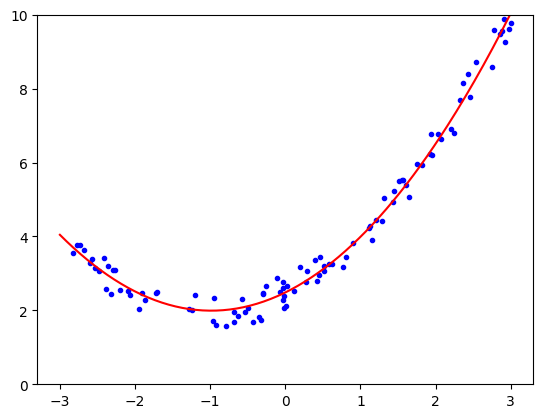

In [125]:
plt.plot(x_pol , y_pol  , "b.")
plt.plot(x_test , y_pred , "r-")
plt.ylim(0 , 10)

In [144]:
print(y_pol.shape)

(100, 1)


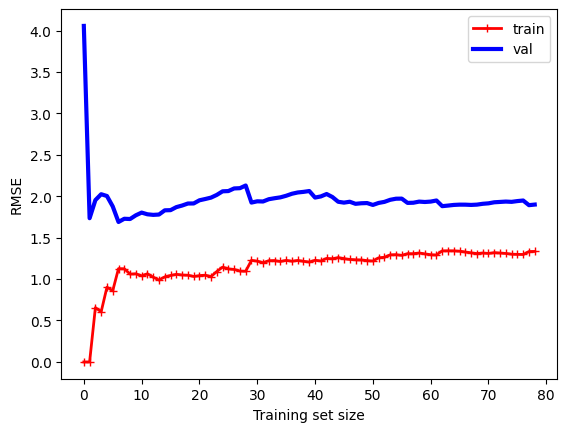

In [146]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

def plot(model, x, y):
    train_error, val_error = [], []
    x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)
    
    for m in range(1, len(x_train)):
        model.fit(x_train[:m], y_train[:m])
        y_train_predict = model.predict(x_train[:m])
        y_val_predict = model.predict(x_val)  # ✓ Use ALL validation data
        
        train_error.append(mean_squared_error(y_train[:m], y_train_predict))
        val_error.append(mean_squared_error(y_val, y_val_predict))  # ✓ Now matches
    
    plt.plot(np.sqrt(train_error), "r-+", linewidth=2, label="train")
    plt.plot(np.sqrt(val_error), "b-", linewidth=3, label="val")
    plt.xlabel("Training set size")
    plt.ylabel("RMSE")
    plt.legend()

lin_regression = LinearRegression()
plot(lin_regression, x_pol, y_pol)